In [15]:
import numpy as np
import pandas as pd
#working with missing values(NA or NaN) in the data frame or tabular data
#create sample data
df = pd.DataFrame([[1,np.nan,2],[2,3,5],[np.nan,4,6]]) #data has no values (NAs) in some cells
#we need to remove NA or NaN from the data frame, because any dataset with NaN is not clean data
print(df.head)
#check if the data frame has na values/missing values
print(df.isnull()) #prints out the entire table with true if null and false if not
#drop the row to remove the null value
print(df.dropna())
#drop the columns if they contain a missing value/na
print(df.dropna(axis=1))
#drop a column only if all cells in that column contain na
print(df.dropna(axis=1, how="all"))
#can also specify the minimum number of non null values in a row/column to be kept
print(df.dropna(thresh=2))
#can replace na values with 0 or any other data
print(df.fillna(0))
#can also forward fill the previous value basically the above column value to the current value
print(df.ffill())
#can also backfill na value with the value of the below column
print(df.bfill())
#columnwise forward fill
print(df.ffill(axis=1))
#columnwise backfill
print(df.bfill(axis=1))
#need to try few permutations and combinations to remove alll the na values

<bound method NDFrame.head of      0    1  2
0  1.0  NaN  2
1  2.0  3.0  5
2  NaN  4.0  6>
       0      1      2
0  False   True  False
1  False  False  False
2   True  False  False
     0    1  2
1  2.0  3.0  5
   2
0  2
1  5
2  6
     0    1  2
0  1.0  NaN  2
1  2.0  3.0  5
2  NaN  4.0  6
     0    1  2
0  1.0  NaN  2
1  2.0  3.0  5
2  NaN  4.0  6
     0    1  2
0  1.0  0.0  2
1  2.0  3.0  5
2  0.0  4.0  6
     0    1  2
0  1.0  NaN  2
1  2.0  3.0  5
2  2.0  4.0  6
     0    1  2
0  1.0  3.0  2
1  2.0  3.0  5
2  NaN  4.0  6
     0    1    2
0  1.0  1.0  2.0
1  2.0  3.0  5.0
2  NaN  4.0  6.0
     0    1    2
0  1.0  2.0  2.0
1  2.0  3.0  5.0
2  4.0  4.0  6.0


In [79]:
#taking real life large dataset with many na values
from pathlib import Path

path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section3/titanic.csv")
df = pd.read_csv(path)
#print the first few rows to get a sense of the data
print(df.head())
#to find out how many rows and cols or the dimensions of the data
print("dimensions: ",df.shape)
#to check how many values each column has, only counts non NA values
df.count()
#how many NA's in my data, gives each column
print("Number of Na's in each column", df.isna().sum())
#Time to start cleaning the missing values.
#drop all the rows/records which have a missing value
dropping_rows = df.dropna()
print("dimesnion after dropping rows ", dropping_rows.shape) #lot of data was lost since now only 183 rows are left
#drop only if all the rows are na
dropping_rows = df.dropna(how="all")
dropping_rows.shape #lost 0 data
#replace missing values with 0
fill_with_zero = df.fillna(0)
fill_with_zero.shape
fill_with_zero.count()#shows all the rows filled, strategy won't work if 0 means something significant
#in such cases, replace with missing values with the mean of the present values for that property, this is called imputing
#copy_df = df.copy()
#copy_df.Age.fillna(copy_df.Age.mean(), inplace=True)
#copy_df.head()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
di

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            891
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          891
Embarked       891
dtype: int64

   0    1   2   3    4     5      6   7  8
0  6  148  72  35    0  33.6  0.627  50  1
1  1   85  66  29    0  26.6  0.351  31  0
2  8  183  64   0    0  23.3  0.672  32  1
3  1   89  66  23   94  28.1  0.167  21  0
4  0  137  40  35  168  43.1  2.288  33  1
Vector of missing values           1      2      3      4      5      6      7
0    False  False  False   True  False  False  False
1    False  False  False   True  False  False  False
2    False  False   True   True  False  False  False
3    False  False  False  False  False  False  False
4    False  False  False  False  False  False  False
..     ...    ...    ...    ...    ...    ...    ...
763  False  False  False  False  False  False  False
764  False  False  False   True  False  False  False
765  False  False  False  False  False  False  False
766  False  False   True   True  False  False  False
767  False  False  False   True  False  False  False

[768 rows x 7 columns]
1      5
2     35
3    227
4    374
5     11
6      0
7 

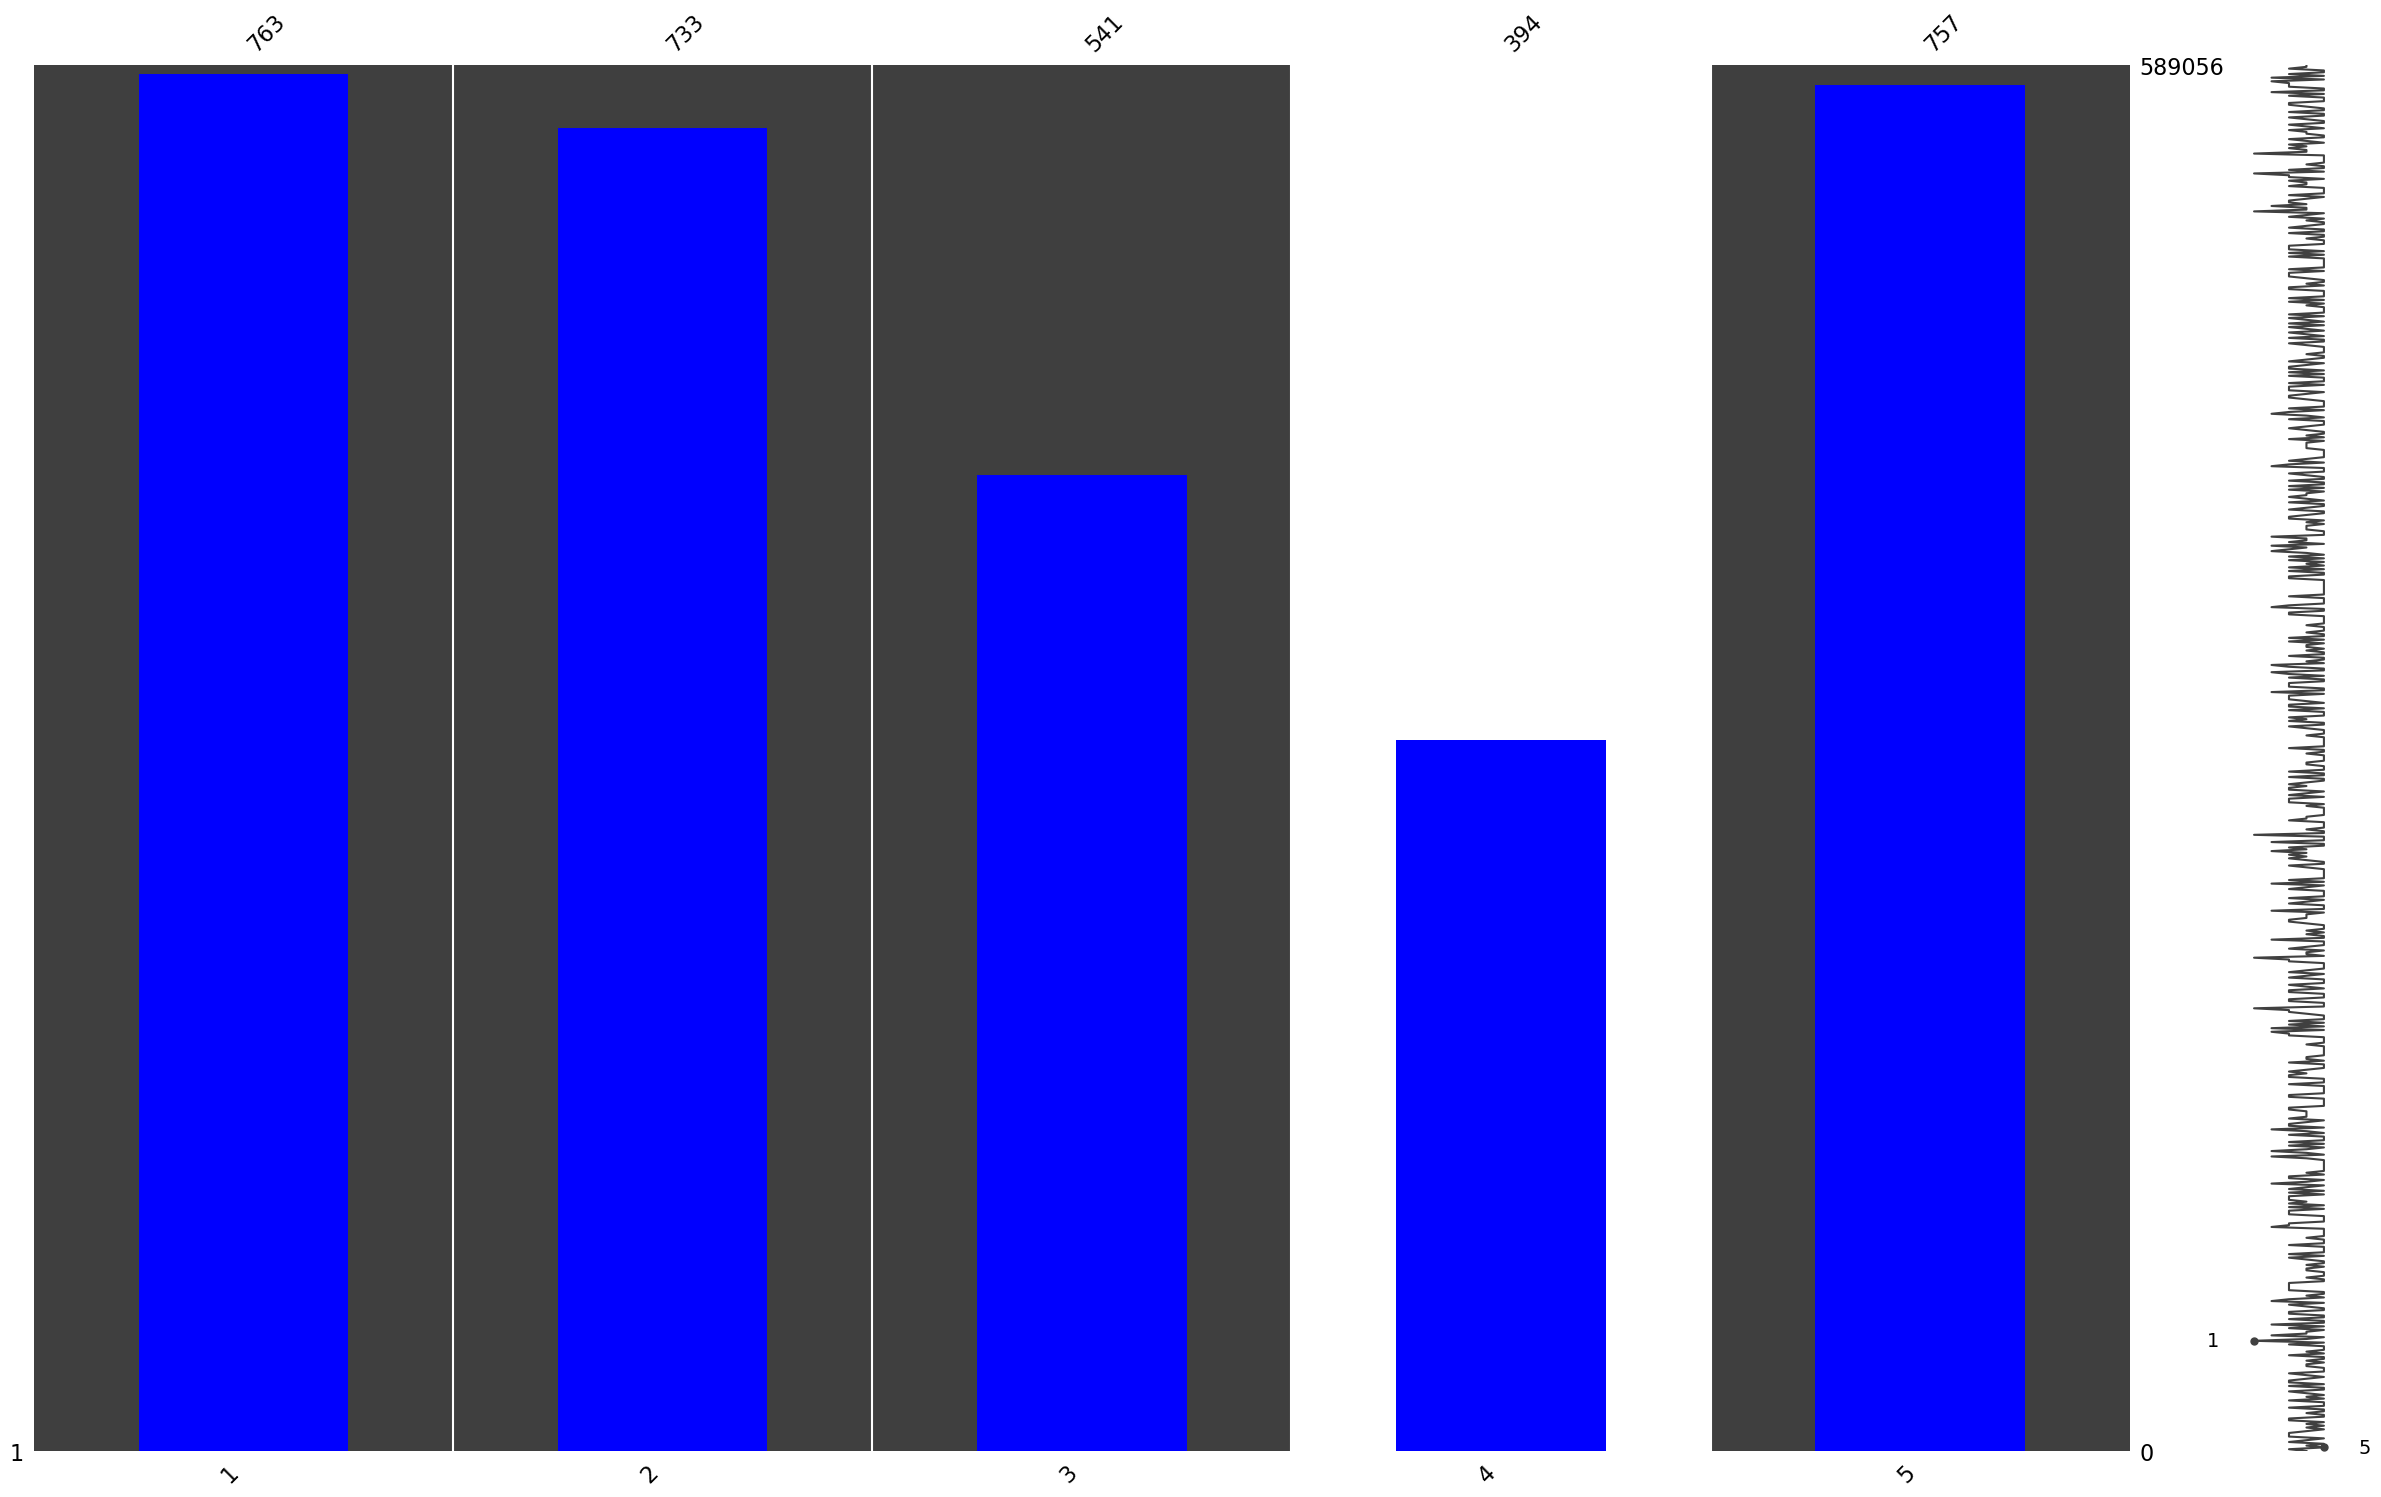

In [85]:
 #data imputing: replacing a missing value with the mean of all non-missing values for that property
#sometimes 0 can be missing values in a data set for example, weight of a new born baby can never be 0 so 0 can be cosnidered as misisng value
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section3/pima-indians-diabetes.csv")
df = pd.read_csv(path, header = None)#no headers in the file
print(df.head())
#calculate the amount if 0's in the columns
print("Vector of missing values ",(df[[1,2,3,4,5,6,7]] == 0))
print((df[[1,2,3,4,5,6,7]] == 0).sum())
#replace 0 values with NaN, 6 and 7 have no misisng values
df[[1,2,3,4,5]] = df[[1,2,3,4,5]].replace(0, np.NaN)
#visualize the missing values and matplotlib is default graph like package available in python#
print("Columns with NaN values ", df.columns[df.isnull().any()])
print("Blah ", df.isnull().any())
print(df.columns[df.isnull().any()].tolist())
#extract only those columns with 0's/missing values
missing_columns = df.columns[df.isnull().any()].tolist()
print("columns datafram with missing values", missing_columns)
import missingno as msno
import matplotlib
msno.matrix(df[missing_columns])#appears as if columns 3 and 4 have a lot of missing values
msno.bar(df[missing_columns], color="blue", log=False, figsize=(30,18))
#try imputing, replacing the missing values with mean of all properties for that table
df.fillna(df.mean(), inplace=True)
print("Missing values after imputing ", df.isnull().sum())
#can also inbuilt imputer for imputing
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()
print("Values of array: ", df.values)
transformed_values = imputer.fit_transform(df.values)
print(np.isnan(transformed_values).sum())
#customize imputer
imp = SimpleImputer(missing_values = np.nan, strategy='mean')#can use median also
transformed_values2 = imp.fit_transform(df.values)
print(np.isnan(transformed_values2).sum())

In [94]:
#impute qualitative values(not numbers like cabin values in titanic.csv file)
#taking mean won't work in this case because rest of the values are not numbers
#so replace the missing values with most common value in that column
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section3/titanic.csv")
df = pd.read_csv(path)
#find the most common string value in that column)
print(df['Cabin'].value_counts()) # returns the table with frequency of few most common values
#replace Nan with most common word for qualitative data
df['Cabin'].fillna(df['Cabin'].value_counts().index[0])
print(df['Cabin'].isnull().sum())

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64
687


In [107]:
#using knn for data inputing, knn is a machine learning algorithm
import numpy as np
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section3/pima-indians-diabetes.csv")
df = pd.read_csv(path, header = None)#no headers in the file
print("First 7 values of OG data set ", df.head(n=7))
#find out how columns have 0 values
(df[[1, 2, 3, 4, 5, 6, 7]] == 0).sum() #first 5 columns have 0 values
#isolate the first 5 columns and replace 0 with missing values(Nan)
import numpy as np
d5 = df[[1, 2, 3, 4, 5]]
d5[[1, 2, 3, 4, 5]] = d5[[1, 2, 3, 4, 5]].replace(0, np.NaN)
print("First 7 values of the replaced data set ", d5.head(n=7))
#use knn alogorithm for imputation
from fancyimpute import KNN, NuclearNormMinimization, SoftImpute, IterativeImputer, BiScaler
#### kNN: Nearest neighbor imputations which weights samples using the mean squared difference on features for which two rows both have observed data.
#### The assumption behind using KNN for imputing missing values is that a point value can be approximated by the values of the points that are closest to it, based on other variables.
#create a new imputed data frame
d5_imp = pd.DataFrame(KNN(k=3).fit_transform(d5))
### Use 3 nearest rows which have a feature to fill in each row's missing features
#KNN Imputation (K-Nearest Neighbors Imputation) is a method for filling in missing data by using the values from similar (neighboring) rows.
#It assumes that similar rows have similar values, so it looks for the "K" nearest rows (neighbors) that don’t have missing values, and uses their values to fill in the gaps.
print(d5_imp.head(n=7))
#### NuclearNormMinimization: Simple implementation of Exact Matrix Completion via Convex Optimization by Emmanuel Candes and Benjamin Recht using cvxpy. Too slow for large matrices
#takes a very long time for large matrices and it should be avoided
#d5_nn = pd.DataFrame(NuclearNormMinimization().fit_transform(d5))
#print(d5_nn.head(n=7))

First 7 values of OG data set     0    1   2   3    4     5      6   7  8
0  6  148  72  35    0  33.6  0.627  50  1
1  1   85  66  29    0  26.6  0.351  31  0
2  8  183  64   0    0  23.3  0.672  32  1
3  1   89  66  23   94  28.1  0.167  21  0
4  0  137  40  35  168  43.1  2.288  33  1
5  5  116  74   0    0  25.6  0.201  30  0
6  3   78  50  32   88  31.0  0.248  26  1
First 7 values of the replaced data set         1     2     3      4     5
0  148.0  72.0  35.0    NaN  33.6
1   85.0  66.0  29.0    NaN  26.6
2  183.0  64.0   NaN    NaN  23.3
3   89.0  66.0  23.0   94.0  28.1
4  137.0  40.0  35.0  168.0  43.1
5  116.0  74.0   NaN    NaN  25.6
6   78.0  50.0  32.0   88.0  31.0


C:\Users\hebbarsh\AppData\Local\Temp\ipykernel_22132\1854819666.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d5[[1, 2, 3, 4, 5]] = d5[[1, 2, 3, 4, 5]].replace(0, np.NaN)


Imputing row 1/768 with 1 missing, elapsed time: 0.221
Imputing row 101/768 with 2 missing, elapsed time: 0.228
Imputing row 201/768 with 1 missing, elapsed time: 0.233
Imputing row 301/768 with 3 missing, elapsed time: 0.238
Imputing row 401/768 with 2 missing, elapsed time: 0.243
Imputing row 501/768 with 0 missing, elapsed time: 0.247
Imputing row 601/768 with 1 missing, elapsed time: 0.251
Imputing row 701/768 with 0 missing, elapsed time: 0.255
       0     1          2           3     4
0  148.0  72.0  35.000000  241.109574  33.6
1   85.0  66.0  29.000000   85.432977  26.6
2  183.0  64.0  31.405589  547.075469  23.3
3   89.0  66.0  23.000000   94.000000  28.1
4  137.0  40.0  35.000000  168.000000  43.1
5  116.0  74.0  15.409388   99.760432  25.6
6   78.0  50.0  32.000000   88.000000  31.0
                                     CVXPY                                     
                                     v1.6.5                                    
(CVXPY) Apr 20 04:37:00 PM: Your p

OverflowError: number of elements exceeds INT_MAX

In [127]:
#Data wrangling: 
#Data Wrangling is the process of cleaning, structuring, and enriching raw data into a format that’s ready for analysis or machine learning.
#Raw data often has issues like:
#Missing values
#Duplicates
#Inconsistent formats
#Irrelevant information
#Wrong data types
#Data wrangling is all about fixing these issues so that you can extract insights or feed the data into a model.
#prelim explore: to get an initial feel of the dataset to know how to clean the data
#1st thing to do is look at the first few rows of the dataset
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section4/Indicators.csv")
indcDf = pd.read_csv(path)
#look at the first 7 rows of the data
indcDf.head(n=7)
#to find out what are the columns
list(indcDf)
print(indcDf.columns)
#what are the datatypes of the values
indcDf.dtypes
#for 1 column, data type
indcDf['Year'].dtype
#statistical summary of all the quantitative data columns(numbers) not qualitative columns
indcDf.describe()
#1. one of the ways to describe the qualitative data is by finding out the unique values for a particular columns or maultiple columns
countries = indcDf['CountryName'].unique().tolist() #list of country names
#number of unique values
print(len(countries))#how many countries?
#to find out the frequency of values in that columns
from collections import Counter
c = Counter(countries)
#print(c)
#counter takes a list so everything needs to be conerted to a list first
ccode = indcDf['CountryCode'].tolist() #list all country codes
cc = Counter(ccode)
print("Most common country code")
print(cc.most_common(1))
print(cc.most_common(2))
print("to columns of indicator")
print(indcDf['IndicatorName'][:20])#called as indexing


Index(['CountryName', 'CountryCode', 'IndicatorName', 'IndicatorCode', 'Year',
       'Value'],
      dtype='object')
247
Most common country code
[('MEX', 37244)]
[('MEX', 37244), ('COL', 37227)]
to columns of indicator
0     Adolescent fertility rate (births per 1,000 wo...
1     Age dependency ratio (% of working-age populat...
2     Age dependency ratio, old (% of working-age po...
3     Age dependency ratio, young (% of working-age ...
4           Arms exports (SIPRI trend indicator values)
5           Arms imports (SIPRI trend indicator values)
6                  Birth rate, crude (per 1,000 people)
7                                    CO2 emissions (kt)
8                CO2 emissions (metric tons per capita)
9     CO2 emissions from gaseous fuel consumption (%...
10    CO2 emissions from liquid fuel consumption (% ...
11      CO2 emissions from liquid fuel consumption (kt)
12    CO2 emissions from solid fuel consumption (% o...
13                 Death rate, crude (per 1,000 peo

In [134]:
#Conditional data selection: deep dive into the data
import pandas as pd
import numpy as np
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section4/endangeredLang.csv")
data = pd.read_csv(path)
data.head(n=6)
#isolate the 2 columns, which has info on the countries the languages belong to
data['Countries']
#isolate the 2 columns
df = data[['Countries', 'Name in English']]
df.head()
#isolate the rows
data[3:20] 

,ID,Name in English,Countries,Country codes alpha 3,Degree of endangerment,Number of speakers,Latitude,Longitude,Description of the location
3,335,Belarusian,"Belarus, Latvia, Lithuania, Poland, Russian Fe...","BRB, LVA, LTU, POL, RUS, UKR",Vulnerable,4000000.0,53.9560,27.5756,Belarus except the Polesian-speaking south-wes...
4,382,Lombard,"Italy, Switzerland","ITA, CHE",Definitely endangered,3500000.0,45.7215,9.3273,the region of Lombardy (except the southernmos...
5,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...","ALB, DEU, AUT, BRB, BIH, BGR, HRV, EST, FIN, F...",Definitely endangered,3500000.0,46.3165,22.3681,"many European countries, most densely in East-..."
6,2211,Yiddish (Israel),Israel,ISR,Definitely endangered,3000000.0,32.0833,34.8333,"most speakers now live outside Europe, mainly ..."
7,1586,Gondi,India,IND,Vulnerable,2713790.0,19.5804,80.4418,"Madhya Pradesh (Betul, Chhindwara, Seoni, Mand..."
8,1020,Limburgian-Ripuarian,"Germany, Belgium, Netherlands","DEU, BEL, NLD",Vulnerable,2600000.0,50.7781,6.0864,Limburg provinces in Belgium and the Netherlan...
9,1943,Quechua of Southern Bolivia,Bolivia (Plurinational State of),BOL,Vulnerable,2300000.0,-18.0675,-65.7641,"Departments of Cochabamba, Chuquisaca, Potosí ..."
10,1565,Kumaoni,"India, Nepal","IND, NPL",Vulnerable,2003783.0,29.4778,79.8486,"Uttarakhand, also in Uttar Pradesh, Madhya Pra..."
11,755,Aymara,"Bolivia (Plurinational State of), Chile, Peru","BOL, CHL, PER",Vulnerable,2000000.0,-16.5835,-68.3020,"Departamentos de Puno, Moquegua y Tacna, en ..."
12,349,Emilian-Romagnol,"Italy, San Marino","ITA, SMR",Definitely endangered,2000000.0,44.1270,12.0739,"the region of Emilia-Romagna, parts of the pro..."


In [138]:
#conditional selection of data
data['Number of speakers'] < 5000
data[data['Number of speakers'] < 5000]

,ID,Name in English,Countries,Country codes alpha 3,Degree of endangerment,Number of speakers,Latitude,Longitude,Description of the location
740,1125,Jirel,Nepal,NPL,Definitely endangered,4919.0,27.6419,86.2123,Dolakha district
741,468,Dolgan,Russian Federation,RUS,Definitely endangered,4865.0,71.3851,97.3388,Dudinka and Khatanga counties in former Taymyr...
742,2057,Romani (Colombia),Colombia,COL,Vulnerable,4858.0,NaN,NaN,Se ubican en los departamentos de Atlántico y ...
743,1160,Tsum,Nepal,NPL,Definitely endangered,4786.0,28.4723,85.0080,banks of Shar river
744,993,Northern Tlapanec,Mexico,MEX,Vulnerable,4771.0,17.4203,-98.7814,"Municipality of Zapotitlán Tablas, state of Gu..."
...,...,...,...,...,...,...,...,...,...
2534,131,|'Auni,South Africa,ZAF,Extinct,0.0,-26.0105,20.3630,NaN
2535,136,|Xam,South Africa,ZAF,Extinct,0.0,-32.2853,20.7590,NaN
2536,1443,ǁKu ǁ'e,South Africa,ZAF,Extinct,0.0,-29.9739,27.0812,Border area of Lesotho and South Africa
2537,1445,ǁKx'au,South Africa,ZAF,Extinct,0.0,-32.2896,21.7968,NaN


In [147]:
#dropping rows
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section4/endangeredLang.csv")
data = pd.read_csv(path)
data.head(n=6)

,ID,Name in English,Countries,Country codes alpha 3,Degree of endangerment,Number of speakers,Latitude,Longitude,Description of the location
0,1022,South Italian,Italy,ITA,Vulnerable,7500000.0,40.9798,15.2490,"Campania, Lucania (Basilicata), Abruzzi (Abruz..."
1,1023,Sicilian,Italy,ITA,Vulnerable,5000000.0,37.4399,14.5019,"Sicily (Sicilia), southern and central Calabri..."
2,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...","DEU, DNK, NLD, POL, RUS",Vulnerable,4800000.0,53.4029,10.3601,"northern Germany, the north-eastern part of th..."
3,335,Belarusian,"Belarus, Latvia, Lithuania, Poland, Russian Fe...","BRB, LVA, LTU, POL, RUS, UKR",Vulnerable,4000000.0,53.9560,27.5756,Belarus except the Polesian-speaking south-wes...
4,382,Lombard,"Italy, Switzerland","ITA, CHE",Definitely endangered,3500000.0,45.7215,9.3273,the region of Lombardy (except the southernmos...
5,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...","ALB, DEU, AUT, BRB, BIH, BGR, HRV, EST, FIN, F...",Definitely endangered,3500000.0,46.3165,22.3681,"many European countries, most densely in East-..."


In [154]:
#for data analysis, data type of the values hsould be data frame
type(data)
df = pd.DataFrame(data)
type(df)
#drop the first row
df.drop(df.index[0], inplace=True)
df.head(6)

,ID,Name in English,Countries,Country codes alpha 3,Degree of endangerment,Number of speakers,Latitude,Longitude,Description of the location
1,1023,Sicilian,Italy,ITA,Vulnerable,5000000.0,37.4399,14.5019,"Sicily (Sicilia), southern and central Calabri..."
2,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...","DEU, DNK, NLD, POL, RUS",Vulnerable,4800000.0,53.4029,10.3601,"northern Germany, the north-eastern part of th..."
3,335,Belarusian,"Belarus, Latvia, Lithuania, Poland, Russian Fe...","BRB, LVA, LTU, POL, RUS, UKR",Vulnerable,4000000.0,53.9560,27.5756,Belarus except the Polesian-speaking south-wes...
4,382,Lombard,"Italy, Switzerland","ITA, CHE",Definitely endangered,3500000.0,45.7215,9.3273,the region of Lombardy (except the southernmos...
5,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...","ALB, DEU, AUT, BRB, BIH, BGR, HRV, EST, FIN, F...",Definitely endangered,3500000.0,46.3165,22.3681,"many European countries, most densely in East-..."
6,2211,Yiddish (Israel),Israel,ISR,Definitely endangered,3000000.0,32.0833,34.8333,"most speakers now live outside Europe, mainly ..."


In [155]:
#dropping multiple rows(first 2 rows)
df.drop(df.index[:2], inplace=True)
df

,ID,Name in English,Countries,Country codes alpha 3,Degree of endangerment,Number of speakers,Latitude,Longitude,Description of the location
3,335,Belarusian,"Belarus, Latvia, Lithuania, Poland, Russian Fe...","BRB, LVA, LTU, POL, RUS, UKR",Vulnerable,4000000.0,53.9560,27.5756,Belarus except the Polesian-speaking south-wes...
4,382,Lombard,"Italy, Switzerland","ITA, CHE",Definitely endangered,3500000.0,45.7215,9.3273,the region of Lombardy (except the southernmos...
5,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...","ALB, DEU, AUT, BRB, BIH, BGR, HRV, EST, FIN, F...",Definitely endangered,3500000.0,46.3165,22.3681,"many European countries, most densely in East-..."
6,2211,Yiddish (Israel),Israel,ISR,Definitely endangered,3000000.0,32.0833,34.8333,"most speakers now live outside Europe, mainly ..."
7,1586,Gondi,India,IND,Vulnerable,2713790.0,19.5804,80.4418,"Madhya Pradesh (Betul, Chhindwara, Seoni, Mand..."
...,...,...,...,...,...,...,...,...,...
2717,1972,Yonaguni,Japan,JPN,Severely endangered,NaN,24.4580,122.9802,Yonaguni Island
2718,2018,Yucuna,Colombia,COL,Definitely endangered,NaN,-1.2633,-70.6640,NaN
2719,2015,Yurutí (Colombia),Colombia,COL,Definitely endangered,NaN,1.1370,-70.2136,NaN
2720,2716,Zangskari,"India, Pakistan","IND, PAK",Definitely endangered,NaN,34.0833,76.8500,NaN


In [158]:
#dropping columns
df.drop(['Latitude'], axis=1, inplace=True)
df

,ID,Name in English,Countries,Country codes alpha 3,Degree of endangerment,Number of speakers,Longitude,Description of the location
3,335,Belarusian,"Belarus, Latvia, Lithuania, Poland, Russian Fe...","BRB, LVA, LTU, POL, RUS, UKR",Vulnerable,4000000.0,27.5756,Belarus except the Polesian-speaking south-wes...
4,382,Lombard,"Italy, Switzerland","ITA, CHE",Definitely endangered,3500000.0,9.3273,the region of Lombardy (except the southernmos...
5,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...","ALB, DEU, AUT, BRB, BIH, BGR, HRV, EST, FIN, F...",Definitely endangered,3500000.0,22.3681,"many European countries, most densely in East-..."
6,2211,Yiddish (Israel),Israel,ISR,Definitely endangered,3000000.0,34.8333,"most speakers now live outside Europe, mainly ..."
7,1586,Gondi,India,IND,Vulnerable,2713790.0,80.4418,"Madhya Pradesh (Betul, Chhindwara, Seoni, Mand..."
...,...,...,...,...,...,...,...,...
2717,1972,Yonaguni,Japan,JPN,Severely endangered,NaN,122.9802,Yonaguni Island
2718,2018,Yucuna,Colombia,COL,Definitely endangered,NaN,-70.6640,NaN
2719,2015,Yurutí (Colombia),Colombia,COL,Definitely endangered,NaN,-70.2136,NaN
2720,2716,Zangskari,"India, Pakistan","IND, PAK",Definitely endangered,NaN,76.8500,NaN


In [161]:
#can drop multiple columns by passing the list of columns to be removed
#changing column names to something more intutive is very helpful in analyzing the data especially if the name has spaces or "/" like race/ethnicity
import pandas as pd
path = Path("C:/Users/hebbarsh/Desktop/IntelliLearn/DataVisualizarioAndWrangling/Dc/DataAndCode/section4/StudentsPerformance.csv")
sp1 = pd.read_csv(path)
sp1.head(n=6)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78


In [162]:
#changing column names when reading the data
new_columns = ['Gender', 'Race', 'Parental_Edu', 'Lunch', 'Tution', 'Maths', 'Reading', 'Writing']
sp2 = pd.read_csv(path, names=new_columns) 
sp2.head(n=6)

,Gender,Race,Parental_Edu,Lunch,Tution,Maths,Reading,Writing
0,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group C,some college,standard,completed,69,90,88
3,female,group B,master's degree,standard,none,90,95,93
4,male,group A,associate's degree,free/reduced,none,47,57,44
5,male,group C,some college,standard,none,76,78,75


In [165]:
#changing the name after reading the data
sp2.rename(columns={'Tution': 'CourseReceived', 'Maths' : 'Mathematics'}, inplace=True)
sp2.head(n=5)

,Gender,Race,Parental_Edu,Lunch,CourseReceived,Mathematics,Reading,Writing
0,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group C,some college,standard,completed,69,90,88
3,female,group B,master's degree,standard,none,90,95,93
4,male,group A,associate's degree,free/reduced,none,47,57,44


In [ ]:
#changing the column type:
#1. if numbers are represented as strings, python cannot computer mathematical computations